In [2]:
from keras.backend import clear_session
clear_session()

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [ ]:
from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import LabelEncoder

In [3]:
data = pd.read_excel("D:/Ruslan/main.xlsx")
print(data.head())
print("Unique conditions (raw):", data['Condition'].unique())

   IMG name  Voltage, V  Current, A Condition
0         1       20.21       2.000     clean
1         2       20.27       2.006     clean
2         3       20.33       2.010     clean
3         4       20.33       2.009     clean
4         5       20.32       2.007     clean
Unique conditions (raw): ['clean' 'water' 'dust' 'snow']


In [ ]:
# 2) LABEL ENCODE THE CONDITION COLUMN
#    Mapping -> {'clean': 0, 'dust': 1, 'snow': 2, 'water': 3}
labelencoder = LabelEncoder()
data['Condition'] = labelencoder.fit_transform(data['Condition'])
print("Unique conditions (encoded):", data['Condition'].unique())

Unique conditions (encoded): [0 3 1 2]


In [5]:
# 3) ADD FULL FILE PATHS TO THE DATAFRAME

image_dir = "D:/Ruslan/main/"
data['ImagePath'] = data['IMG name'].apply(
    lambda x: os.path.join(image_dir, f"{x}.jpg")
)
print(data[['IMG name','Condition','ImagePath']].head())

   IMG name  Condition             ImagePath
0         1          0  D:/Ruslan/main/1.jpg
1         2          0  D:/Ruslan/main/2.jpg
2         3          0  D:/Ruslan/main/3.jpg
3         4          0  D:/Ruslan/main/4.jpg
4         5          0  D:/Ruslan/main/5.jpg


In [ ]:
# 4) CUSTOM SPLIT: HARDCODED TEST RANGES PER CONDITION
#    (CLEAN, WATER, DUST, SNOW)

def assign_split(row):
    img_name = row['IMG name']
    cond = row['Condition']
    
    if cond == 0:  # clean
        if 428 <= img_name <= 603:
            return 'test'
        else:
            return 'train_val'
    elif cond == 3:  # water
        if 1006 <= img_name <= 1156:
            return 'test'
        else:
            return 'train_val'
    elif cond == 1:  # dust
        if 2901 <= img_name <= 3029:
            return 'test'
        else:
            return 'train_val'
    elif cond == 2:  # snow
        if 3370 <= img_name <= 3630:
            return 'test'
        else:
            return 'train_val'
    else:
        return 'train_val'

data['Split'] = data.apply(assign_split, axis=1)

test_data = data[data['Split'] == 'test'].copy()
train_val_data = data[data['Split'] == 'train_val'].copy()

In [7]:
# split train_val data into train and validation
# train_data = 66.255%, val_data = 15.29%, test_data = 18.4%

train_data, val_data = train_test_split(
    train_val_data, test_size = 0.1875,
    random_state = 42,
    stratify = train_val_data['Condition']
)

print("Train data size:", train_data.shape[0])
print("Validation data size:", val_data.shape[0])
print("Test data size:", test_data.shape[0])

# print("\nClass distribution in train_data:")
# print(train_data['Condition'].value_counts())

# print("\nClass distribution in val_data:")
# print(val_data['Condition'].value_counts())

# print("\nClass distribution in test_data:")
# print(test_data['Condition'].value_counts())

Train data size: 2846
Validation data size: 657
Test data size: 717


In [ ]:
#5 dataset prepatation pipeline
IMG_SIZE = (224, 224)

def load_image_and_labels(filename, condition, voltage, current, augment=False):
    """Load + decode + resize. If augment=True, apply data_aug. Returns (image, label_dict)."""
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    regression_values = tf.stack([voltage, current], axis=-1)

    return image, {
        #'condition': condition_one_hot,
        'regression': regression_values
    }

def df_to_dataset(df, shuffle = True, batch_size = 32, augment = False):
    filenames = df['ImagePath'].values
    conditions = df['Condition'].values
    voltages = df['Voltage, V'].values
    currents = df['Current, A'].values

    ds = tf.data.Dataset.from_tensor_slices((filenames, conditions, voltages, currents))
    if shuffle:
        ds = ds.shuffle(buffer_size = len(df), reshuffle_each_iteration = True)
    ds = ds.map(lambda f, c, v, i: load_image_and_labels(f, c, v, i, augment = augment),
                num_parallel_calls = tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
train_ds = df_to_dataset(train_data, shuffle=True,  batch_size=32, augment=False)
val_ds   = df_to_dataset(val_data,   shuffle=False, batch_size=32, augment=False)
test_ds  = df_to_dataset(test_data,  shuffle=False, batch_size=32, augment=False)

In [ ]:
def build_vgg_one_block(input_shape=(224, 224, 3), num_regression_outputs=2):
    """
    Builds a VGG-inspired model with the first three blocks and a regression head.

    Args:
        input_shape: Shape of the input images (e.g., (256, 341, 3)).
        num_regression_outputs: Number of regression outputs (e.g., 2 for Voltage and Current).

    Returns:
        A Keras Model instance.
    """
    inputs = layers.Input(shape=input_shape)

    # First block (Block 1)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1')(inputs)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool')(x)

    # # Second block (Block 2)
    # x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1')(x)
    # x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2')(x)
    # x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool')(x)

    # # Third block (Block 3)
    # x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1')(x)
    # x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2')(x)
    # x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3')(x)
    # x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool')(x)

    # Flatten and Fully Connected Regression Head
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5, name='dropout1')(x)

    # Output regression layer
    outputs = layers.Dense(num_regression_outputs, activation='linear', name='regression')(x)

    # Create model
    model = models.Model(inputs=inputs, outputs=outputs, name='VGG_One_Block_Regression')

    return model

In [ ]:
class RSquaredMetric(metrics.Metric):
    def __init__(self, name="r_squared", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total_sum_of_squares = self.add_weight(name="total_ss", initializer="zeros")
        self.residual_sum_of_squares = self.add_weight(name="residual_ss", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        residuals = y_true - y_pred
        total = y_true - tf.reduce_mean(y_true)

        self.residual_sum_of_squares.assign_add(tf.reduce_sum(tf.square(residuals)))
        self.total_sum_of_squares.assign_add(tf.reduce_sum(tf.square(total)))

    def result(self):
        r2 = 1 - (self.residual_sum_of_squares / self.total_sum_of_squares)
        return r2

    def reset_states(self):
        self.total_sum_of_squares.assign(0.0)
        self.residual_sum_of_squares.assign(0.0)

model = build_vgg_one_block(input_shape=(224, 224, 3), num_regression_outputs=2)

In [ ]:
r_squared_metric = RSquaredMetric()
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.MeanSquaredError(),
    metrics=[metrics.MeanSquaredError(), r_squared_metric]
)

save_dir = "D:/Ruslan/ModelWeights/"
os.makedirs(save_dir, exist_ok=True)
weights_path = os.path.join(save_dir, "vgg_one_block_weights_epoch200_batch32_224x224.h5")

checkpoint_cb = ModelCheckpoint(
    filepath=weights_path,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=200,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[checkpoint_cb, early_stopping_cb]
) 

Epoch 1/200
89/89 [==============================] - ETA: 0s - loss: 16.8864 - mean_squared_error: 16.8864 - r_squared: 0.7497

c:\Users\lab311\miniconda3\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric RSquaredMetric implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()



Epoch 1: val_loss improved from inf to 5.45836, saving model to D:/Ruslan/ModelWeights\vgg_one_block_weights_epoch200_batch32_224x224.h5
89/89 [==============================] - 241s 3s/step - loss: 16.8864 - mean_squared_error: 16.8864 - r_squared: 0.7497 - val_loss: 5.4584 - val_mean_squared_error: 5.4584 - val_r_squared: 0.9199
Epoch 2/200
89/89 [==============================] - ETA: 0s - loss: 9.1267 - mean_squared_error: 9.1267 - r_squared: 0.8648
Epoch 2: val_loss improved from 5.45836 to 5.07168, saving model to D:/Ruslan/ModelWeights\vgg_one_block_weights_epoch200_batch32_224x224.h5
89/89 [==============================] - 236s 3s/step - loss: 9.1267 - mean_squared_error: 9.1267 - r_squared: 0.8648 - val_loss: 5.0717 - val_mean_squared_error: 5.0717 - val_r_squared: 0.9256
Epoch 3/200
89/89 [==============================] - ETA: 0s - loss: 7.7063 - mean_squared_error: 7.7063 - r_squared: 0.8858
Epoch 3: val_loss did not improve from 5.07168
89/89 [===========================

In [ ]:
test_loss, test_mse, test_r2 = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}, Test MSE: {test_mse}, Test R^2: {test_r2}")

23/23 [==============================] - 44s 2s/step - loss: 27.7993 - mean_squared_error: 27.7993 - r_squared: -0.2631
Test Loss: 27.799299240112305, Test MSE: 27.799299240112305, Test R^2: -0.26305723190307617


23/23 [==============================] - 43s 2s/step - loss: 27.7993 - mean_squared_error: 27.7993 - r_squared: -0.2631


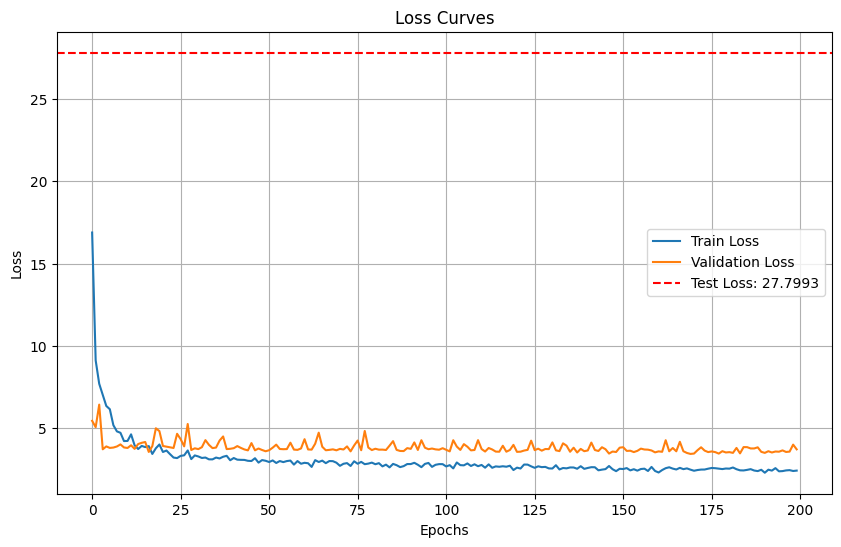

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

test_loss, test_mse, test_r2 = model.evaluate(test_ds)
plt.axhline(test_loss, color='red', linestyle='--', label=f'Test Loss: {test_loss:.4f}')

plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.summary()

Model: "VGG_One_Block_Regression"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 flatten (Flatten)           (None, 802816)            0         
                                                                 
 fc1 (Dense)                 (None, 256)               205521152 
                                                                 
 dropout1 (Dropout)          (None, 256)  

1/1 [==============================] - 0s 33ms/step


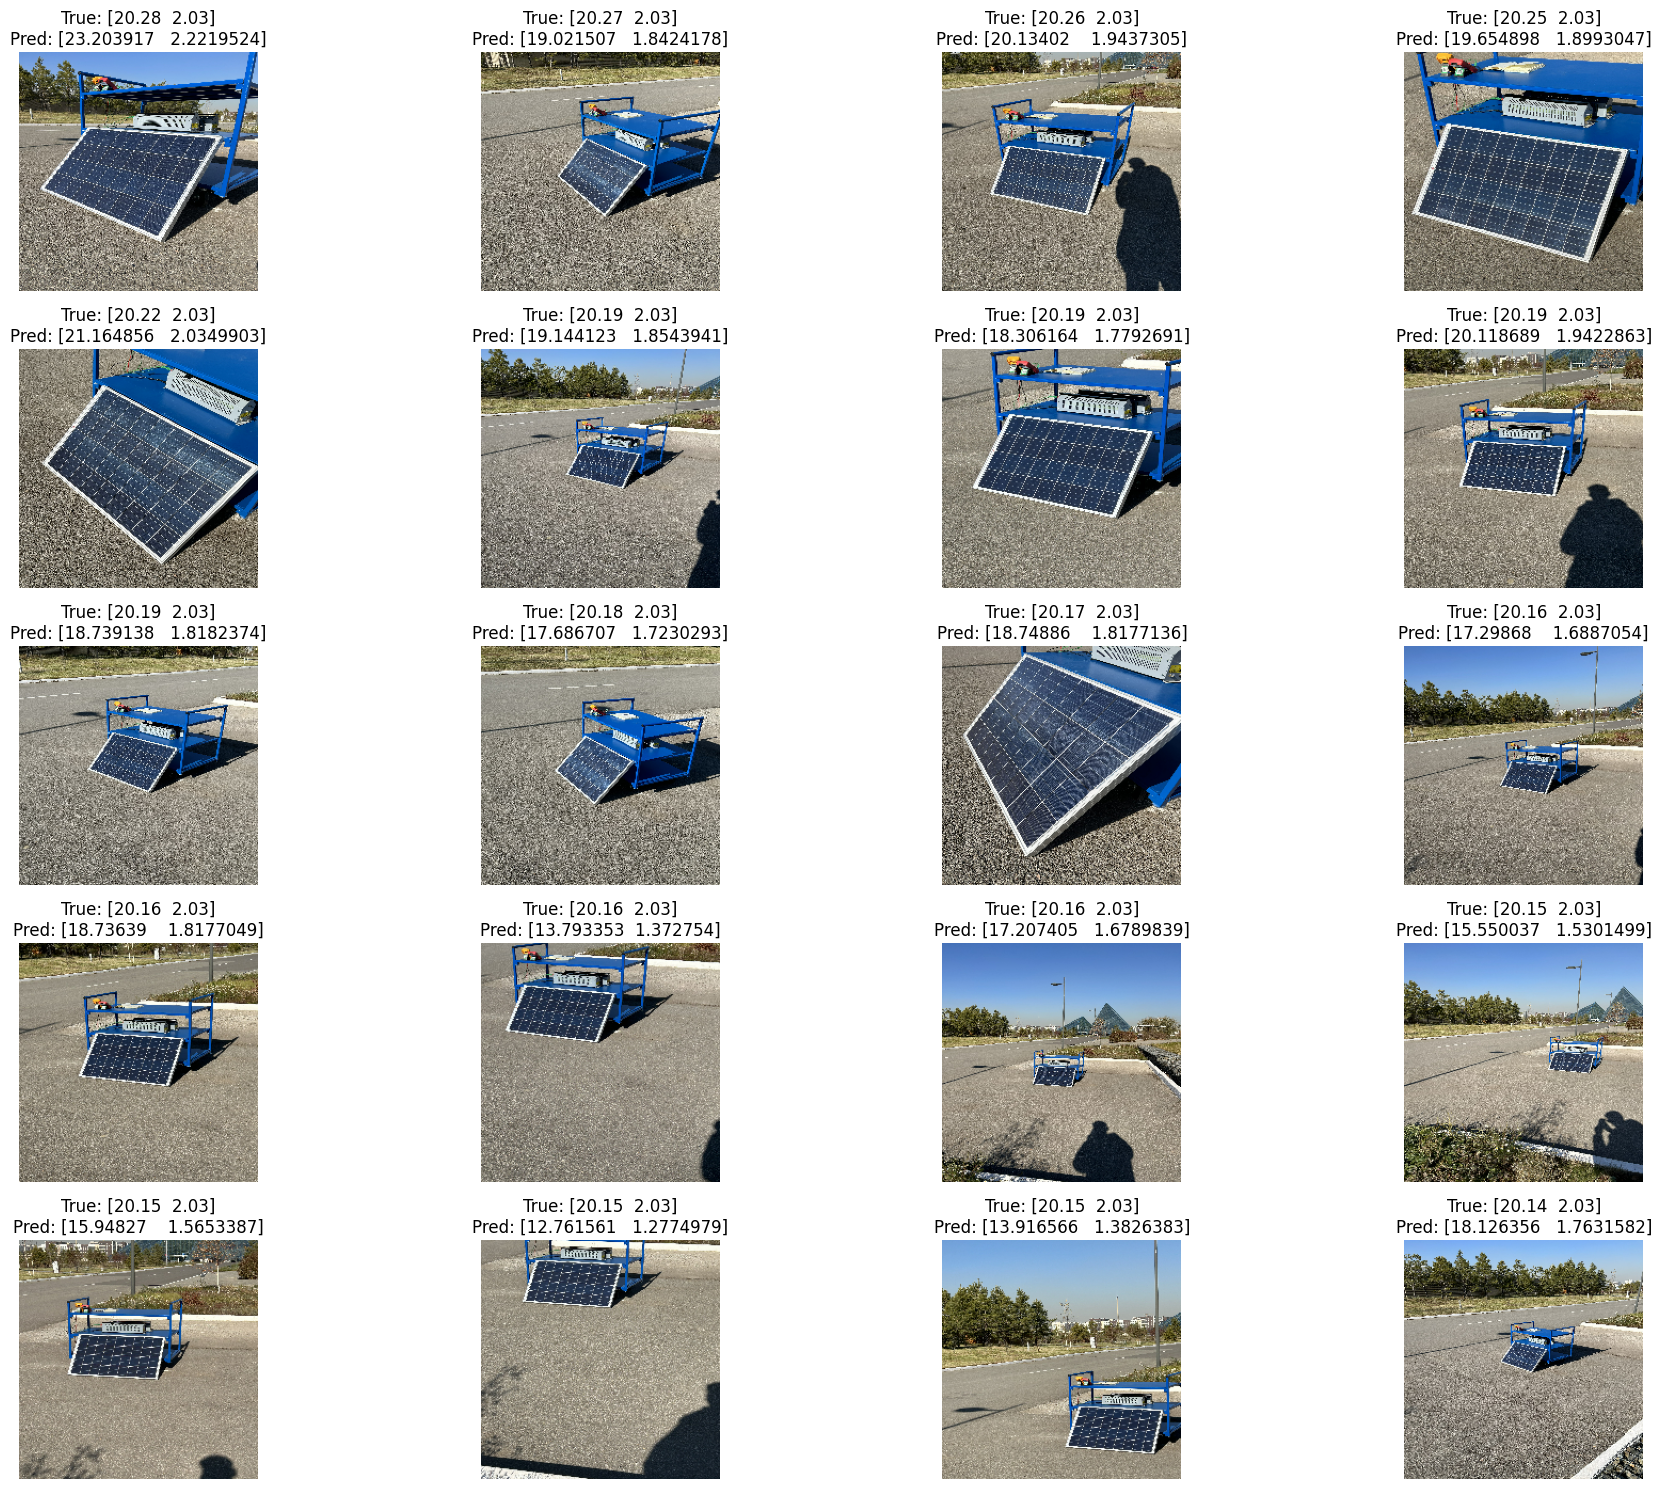

In [ ]:
def show_sample_predictions(test_ds, model, sample_count=20):
    import matplotlib.pyplot as plt

    predictions = []
    true_labels = []
    images = []

    for image_batch, label_batch in test_ds.take(sample_count):
        preds = model.predict(image_batch)
        predictions.extend(preds)
        true_labels.extend(label_batch['regression'].numpy())
        images.extend(image_batch.numpy())

    # Plot predictions vs true labels for sample images
    fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 15))
    axes = axes.flatten()

    for idx, ax in enumerate(axes[:sample_count]):
        if idx >= len(images):
            break
        ax.imshow(images[idx])
        ax.axis('off')
        ax.set_title(f"True: {true_labels[idx]}\nPred: {predictions[idx]}")

    plt.tight_layout()
    plt.show()

# Show predictions for 20 images
show_sample_predictions(test_ds, model, sample_count=20)